In [1]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import  train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from  sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE 



In [7]:
df = pd.read_csv("winequality-red.csv", sep= ";")

df['label'] = df['quality'].apply(lambda x: 1 if x > 7  else 0)


df = df.drop('quality', axis =1)

In [8]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [11]:
## train and test 

X = df.drop('label', axis = 1)
Y = df['label']


X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 42, stratify = Y )

In [12]:
## balamce the data by smote 

smote = SMOTE(random_state =42)
X_train_res,Y_train_res = smote.fit_resample(X_train,Y_train)


# print class distribution after balancing 
print("after smote :", np.bincount(Y_train_res))

after smote : [1265 1265]


In [14]:
# intislazing and training gradient boosting 

gb_model = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 42
)

gb_model.fit(X_train_res,Y_train_res)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [15]:
## prediction repiort
Y_pred = gb_model.predict(X_test)

## classification report 
print("classidicaton report: \n", classification_report(Y_test,Y_pred))

classidicaton report: 
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       316
           1       0.00      0.00      0.00         4

    accuracy                           0.96       320
   macro avg       0.49      0.49      0.49       320
weighted avg       0.97      0.96      0.97       320



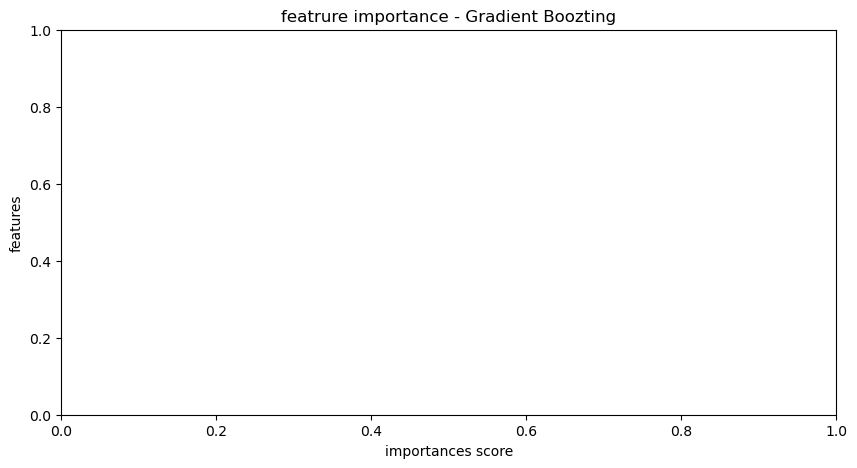

In [16]:
importances = gb_model.feature_importances_
features = X.columns

## bar plot 
plt.figure(figsize= (10,5))
sns.barplot(X=importances, Y=features)
plt.title("featrure importance - Gradient Boozting")
plt.xlabel("importances score")
plt.ylabel("features")
plt.show()